In [77]:
import pandas as pd

df = pd.read_csv("quanta_physics_articles.csv")
df.head()

,Title,Author,Date,Summary,Processed_text
0,Gravity Seems Holographic. What Does That Mean...,Charlie Wood,"September 25, 2026",The biggest breakthrough in modern theoretical...,biggest breakthrough modern theoretical physic...
1,"Biology Might Not Be Quantum, but Its Math Is ...",Elise Cutts,"September 23, 2026",Scientists have a history of trying — and fail...,scientist history trying failing link biology ...
2,Where Does the Quantum World End and Ours Begin?,Steven Strogatz,"September 17, 2026",Jonathan Halliwell explains how quantum decohe...,jonathan halliwell explains quantum decoherenc...
3,Black Holes or Black Hole Stars? Astronomers S...,Charlie Wood,"September 14, 2026",The James Webb Space Telescope spots mysteriou...,james webb space telescope spot mysterious lit...
4,"In Hilbert Space, All Things Are Quantumly Pos...",Charlie Wood,"August 26, 2026","To explore quantum phenomena, we must leave th...",explore quantum phenomenon must leave familiar...


In [78]:
text = df["Summary"]
text.head()

,Summary
0,The biggest breakthrough in modern theoretical...
1,Scientists have a history of trying — and fail...
2,Jonathan Halliwell explains how quantum decohe...
3,The James Webb Space Telescope spots mysteriou...
4,"To explore quantum phenomena, we must leave th..."



**Mengubah semua huruf menjadi huruf kecil (Case Folding)**



In [79]:
df["Summary_lower"] = df["Summary"].str.lower()

# Membandingkan sebelum dan sesudah case folding
df[["Summary", "Summary_lower"]].head()

,Summary,Summary_lower
0,The biggest breakthrough in modern theoretical...,the biggest breakthrough in modern theoretical...
1,Scientists have a history of trying — and fail...,scientists have a history of trying — and fail...
2,Jonathan Halliwell explains how quantum decohe...,jonathan halliwell explains how quantum decohe...
3,The James Webb Space Telescope spots mysteriou...,the james webb space telescope spots mysteriou...
4,"To explore quantum phenomena, we must leave th...","to explore quantum phenomena, we must leave th..."


**Cleaning**

In [80]:

import re
import pandas as pd

def clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()

    # Menghapus URL
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Mengubah kontraksi negatif menjadi bentuk lengkap
    text = re.sub(r"\bcan't\b", "cannot", text)
    text = re.sub(r"\bwon't\b", "will not", text)
    text = re.sub(r"\bshan't\b", "shall not", text)
    text = re.sub(r"n't\b", " not", text)

    # Mengganti karakter selain huruf dengan spasi
    text = re.sub(r"[^a-z\s]", " ", text)

    # Menghapus spasi berlebihan
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["Summary_clean"] = df["Summary"].apply(clean_text)

df[["Summary", "Summary_clean"]].head()


,Summary,Summary_clean
0,The biggest breakthrough in modern theoretical...,the biggest breakthrough in modern theoretical...
1,Scientists have a history of trying — and fail...,scientists have a history of trying and failin...
2,Jonathan Halliwell explains how quantum decohe...,jonathan halliwell explains how quantum decohe...
3,The James Webb Space Telescope spots mysteriou...,the james webb space telescope spots mysteriou...
4,"To explore quantum phenomena, we must leave th...",to explore quantum phenomena we must leave the...


**Tokenisasi**

In [81]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
from nltk.tokenize import word_tokenize

df["Tokens"] = df["Summary_clean"].apply(word_tokenize)

df[["Summary_clean", "Tokens"]].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,Summary_clean,Tokens
0,the biggest breakthrough in modern theoretical...,"[the, biggest, breakthrough, in, modern, theor..."
1,scientists have a history of trying and failin...,"[scientists, have, a, history, of, trying, and..."
2,jonathan halliwell explains how quantum decohe...,"[jonathan, halliwell, explains, how, quantum, ..."
3,the james webb space telescope spots mysteriou...,"[the, james, webb, space, telescope, spots, my..."
4,to explore quantum phenomena we must leave the...,"[to, explore, quantum, phenomena, we, must, le..."


**Stopword Removal**

In [82]:

import nltk
nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

# Kata negasi jangan dihapus
negation_words = {
    "no", "not", "nor", "never",
    "neither", "nobody", "nothing",
    "nowhere", "cannot"
}

stop_words = stop_words - negation_words

df["Tokens_no_stop"] = df["Tokens"].apply(
    lambda words: [
        word for word in words
        if word not in stop_words
    ]
)

df[["Tokens", "Tokens_no_stop"]].head()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Tokens,Tokens_no_stop
0,"[the, biggest, breakthrough, in, modern, theor...","[biggest, breakthrough, modern, theoretical, p..."
1,"[scientists, have, a, history, of, trying, and...","[scientists, history, trying, failing, link, b..."
2,"[jonathan, halliwell, explains, how, quantum, ...","[jonathan, halliwell, explains, quantum, decoh..."
3,"[the, james, webb, space, telescope, spots, my...","[james, webb, space, telescope, spots, mysteri..."
4,"[to, explore, quantum, phenomena, we, must, le...","[explore, quantum, phenomena, must, leave, fam..."


**Lemmatization**

In [83]:
from nltk.stem import WordNetLemmatizer

nltk.download("wordnet")
nltk.download("omw-1.4")

lemmatizer = WordNetLemmatizer()

df["Lemma"] = df["Tokens_no_stop"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

df[["Tokens_no_stop", "Lemma"]].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


,Tokens_no_stop,Lemma
0,"[biggest, breakthrough, modern, theoretical, p...","[biggest, breakthrough, modern, theoretical, p..."
1,"[scientists, history, trying, failing, link, b...","[scientist, history, trying, failing, link, bi..."
2,"[jonathan, halliwell, explains, quantum, decoh...","[jonathan, halliwell, explains, quantum, decoh..."
3,"[james, webb, space, telescope, spots, mysteri...","[james, webb, space, telescope, spot, mysterio..."
4,"[explore, quantum, phenomena, must, leave, fam...","[explore, quantum, phenomenon, must, leave, fa..."


In [84]:
# Menampilkan hasil setiap tahap text preprocessing
df[
    [
        "Summary",
        "Summary_lower",
        "Summary_clean",
        "Tokens",
        "Tokens_no_stop",
        "Lemma"
    ]
].head(3)

,Summary,Summary_lower,Summary_clean,Tokens,Tokens_no_stop,Lemma
0,The biggest breakthrough in modern theoretical...,the biggest breakthrough in modern theoretical...,the biggest breakthrough in modern theoretical...,"[the, biggest, breakthrough, in, modern, theor...","[biggest, breakthrough, modern, theoretical, p...","[biggest, breakthrough, modern, theoretical, p..."
1,Scientists have a history of trying — and fail...,scientists have a history of trying — and fail...,scientists have a history of trying and failin...,"[scientists, have, a, history, of, trying, and...","[scientists, history, trying, failing, link, b...","[scientist, history, trying, failing, link, bi..."
2,Jonathan Halliwell explains how quantum decohe...,jonathan halliwell explains how quantum decohe...,jonathan halliwell explains how quantum decohe...,"[jonathan, halliwell, explains, how, quantum, ...","[jonathan, halliwell, explains, quantum, decoh...","[jonathan, halliwell, explains, quantum, decoh..."


In [85]:
df["Processed_text"] = df["Lemma"].apply(
    lambda words: " ".join(words)
)

df[["Summary", "Processed_text"]].head()

,Summary,Processed_text
0,The biggest breakthrough in modern theoretical...,biggest breakthrough modern theoretical physic...
1,Scientists have a history of trying — and fail...,scientist history trying failing link biology ...
2,Jonathan Halliwell explains how quantum decohe...,jonathan halliwell explains quantum decoherenc...
3,The James Webb Space Telescope spots mysteriou...,james webb space telescope spot mysterious lit...
4,"To explore quantum phenomena, we must leave th...",explore quantum phenomenon must leave familiar...


**Melihat kata yang sering muncul menggunakan WordCloud dan Bar Chart**

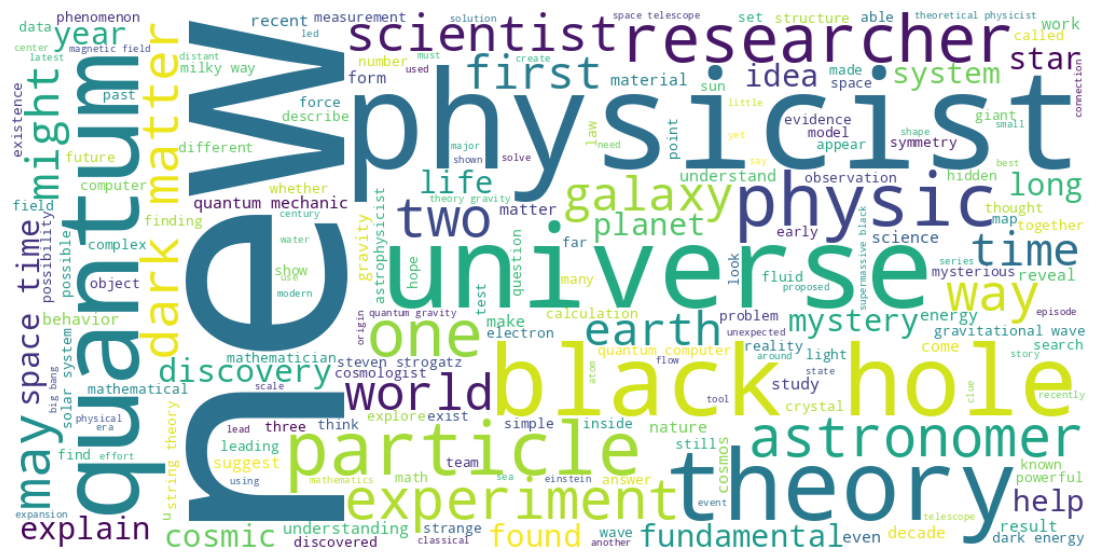

In [86]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = []

for words in df["Lemma"]:
    all_words.extend(words)

text_for_wordcloud = " ".join(all_words)
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text_for_wordcloud)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

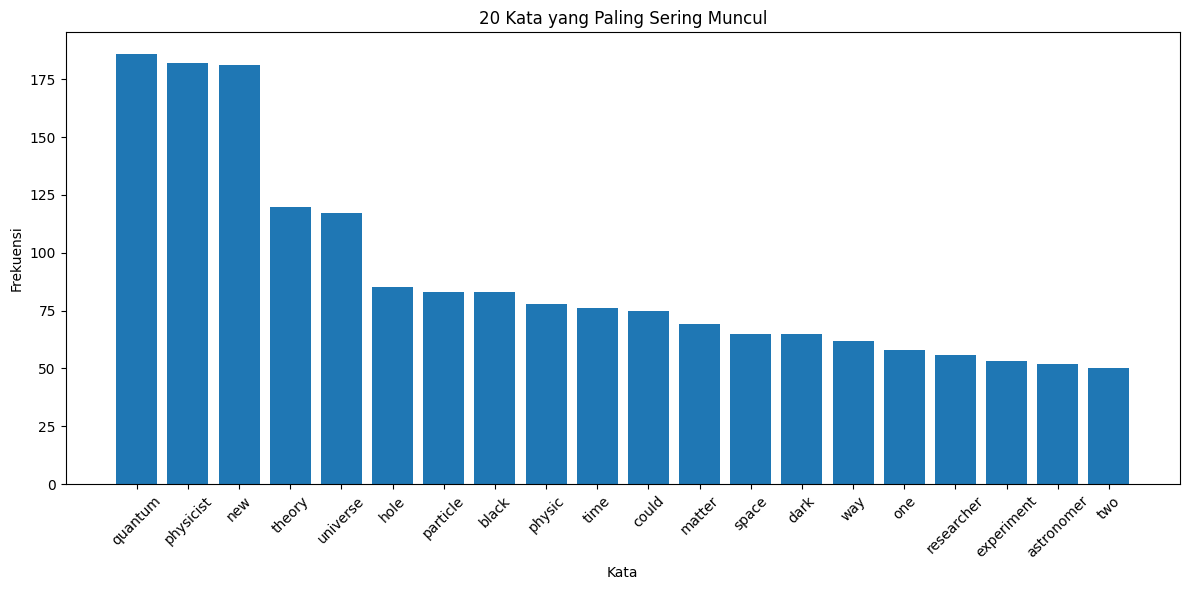

In [87]:
from collections import Counter
import matplotlib.pyplot as plt

word_frequency = Counter(all_words)

top_words = word_frequency.most_common(20)

words = [word for word, count in top_words]
frequencies = [count for word, count in top_words]

plt.figure(figsize=(12, 6))
plt.bar(words, frequencies)

plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.title("20 Kata yang Paling Sering Muncul")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [88]:
print("Jumlah data:", len(df))
print("Summary kosong:", df["Summary"].isna().sum())
print("Summary_clean kosong:", (df["Summary_clean"] == "").sum())
print("Processed_text kosong:", (df["Processed_text"] == "").sum())
print("Jumlah duplikat Title:", df.duplicated(subset="Title").sum())

Jumlah data: 775
Summary kosong: 0
Summary_clean kosong: 0
Processed_text kosong: 0
Jumlah duplikat Title: 0


In [89]:
df.to_csv("quanta_physics_preprocessing(2).csv", index=False)

print("File berhasil disimpan!")

In [91]:
from google.colab import files

files.download("quanta_physics_preprocessing.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [92]:
#EXCERCISE 5

#A. Import library dan membaca data
import warnings
warnings.filterwarnings(action='ignore')

import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv('quanta_physics_preprocessing.csv')

df = df.dropna(subset=['Processed_text']).reset_index(drop=True)
df_pre = df['Processed_text'].astype(str)

df_pre.head()

,Processed_text
0,biggest breakthrough modern theoretical physic...
1,scientist history trying failing link biology ...
2,jonathan halliwell explains quantum decoherenc...
3,james webb space telescope spot mysterious lit...
4,explore quantum phenomenon must leave familiar...


In [96]:
#B. One Hot Encoding
vectorizer = CountVectorizer(binary=True)

X = vectorizer.fit_transform(df_pre)

df_onehot = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

df_onehot

#Analisis hasil:
#Setiap baris mewakili satu artikel atau dokumen.
#Setiap kolom mewakili satu kata unik dalam dataset.
#Nilai 1 berarti kata tersebut muncul dalam dokumen, sedangkan 0 berarti kata tersebut tidak muncul.
#Karena menggunakan binary=True, kata yang muncul berkali-kali tetap diberi nilai 1.

,abandon,aberration,able,absence,abstract,abstraction,abundance,academia,accelerate,accelerated,...,young,youthful,yunger,zebra,zeilinger,zero,zeroing,zone,zoo,zoomable
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
771,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
772,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
773,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [97]:

# 3. Periksa apakah kata negatif masuk ke fitur
fitur = vectorizer.get_feature_names_out()

kata_negatif = ["not", "no", "nor", "never", "cannot"]

for kata in kata_negatif:
    if kata in fitur:
        print(kata, "tersedia sebagai fitur")
    else:
        print(kata, "tidak ditemukan sebagai fitur")


not tersedia sebagai fitur
no tersedia sebagai fitur
nor tersedia sebagai fitur
never tersedia sebagai fitur
cannot tidak ditemukan sebagai fitur


In [94]:
#C. Count Vectorization
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df_pre)

df_count = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

df_count

#Analisis hasil:
#Bentuk tabelnya mirip dengan One Hot Encoding.
#Perbedaannya, nilai pada tabel menunjukkan jumlah kemunculan kata dalam setiap artikel.
#Misalnya, jika kata quantum muncul tiga kali dalam satu artikel, nilainya adalah 3, bukan 1.
#Hasil ini dapat membantu melihat kata yang sering digunakan dalam suatu artikel.

,abandon,aberration,able,absence,abstract,abstraction,abundance,academia,accelerate,accelerated,...,young,youthful,yunger,zebra,zeilinger,zero,zeroing,zone,zoo,zoomable
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
771,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
772,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
773,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [95]:
#D. TF-IDF
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df_pre)

df_tfidf = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)

df_tfidf

#Analisis hasil:
#Setiap baris mewakili artikel dan setiap kolom mewakili kata.
#Nilai pada tabel menunjukkan bobot TF-IDF suatu kata dalam artikel.
#Kata yang sering muncul dalam sebuah artikel dapat memperoleh bobot tinggi, tetapi bobotnya juga dipengaruhi oleh seberapa umum kata tersebut di seluruh dokumen.
#Kata yang muncul di banyak artikel cenderung memiliki nilai IDF lebih rendah, sedangkan kata yang lebih khas pada artikel tertentu dapat memiliki bobot lebih tinggi.

,abandon,aberration,able,absence,abstract,abstraction,abundance,academia,accelerate,accelerated,...,young,youthful,yunger,zebra,zeilinger,zero,zeroing,zone,zoo,zoomable
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.339146,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
770,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
771,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
772,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
773,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
